In [44]:
import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u
import astropy.constants as c
from astropy.io import fits
from scipy.integrate import simps
from astropy.table import Table
from scipy.optimize import curve_fit
from scipy.special import erf
from matplotlib import rc
from numpy.polynomial import chebyshev as ch
import numpy.polynomial as P
rc('font',**{'family':'serif','serif':['Palatino']})
rc('text', usetex=True)

In [11]:
def deg_to_rad(theta):
    return theta * (np.pi/180)

In [12]:
def helio_to_lsr(vhelio,glon,glat):
    glon,glat = deg_to_rad(glon),deg_to_rad(glat)
    
    lon0,lat0 = 22.7,56.16
    
    lon0,lat0 = deg_to_rad(lon0),deg_to_rad(lat0)
    
    v_lsr = vhelio + 19.7*(np.sin(glat) * np.sin(lat0) + np.cos(glat) * np.cos(lat0) * np.cos(glon-lon0))
    return v_lsr



In [356]:
fname = '../Data/SII1250.txt'
wl,flux,err = np.genfromtxt(fname).T
l0 = 1250.58 #Angstrom
f = 5.34e-3
f_53 = 9.95e-03
l0_53 = 1253.8110

vel = 299792.458*(wl - l0)/l0 #Heliocentric velocity

vel_lsr = helio_to_lsr(vel,277.2,-35.4)
max(wl)

1253.6924

In [14]:
%matplotlib
plt.step(vel_lsr,flux)
plt.show()

Using matplotlib backend: MacOSX


In [29]:
vel_masks = [[-28.,42.],[200.,315]]
mask1 = vel_lsr <= -28.
mask2 = (vel_lsr>= 42.) & (vel_lsr <= 200.)
mask3 = vel_lsr>=315.

tot_mask1 = np.logical_or(mask1,mask2)
tot_mask = np.logical_or(tot_mask1,mask3)

In [30]:
vel_masked = vel_lsr[tot_mask]
flux_masked = flux[tot_mask]
err_masked = err[tot_mask]

In [232]:
degree = 7
popt = np.polyfit(vel_masked,flux_masked,deg=degree,w=1/err_masked**2)
cont = np.polyval(popt,vel_lsr)

In [233]:
popt.convert(kind=P.polynomial)

AttributeError: 'numpy.ndarray' object has no attribute 'convert'

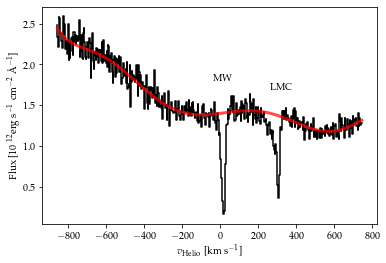

In [354]:
%matplotlib inline
plt.step(vel,1e12 * flux,'k-')
plt.plot(vel,1e12 *cont,'r-',linewidth=3.,alpha=0.7)

plt.xlabel(r'$v_{\rm{Helio}}$ [km s$^{-1}$]')
plt.ylabel(r'Flux [10 $^{12}$erg s$^{-1}$ cm$^{-2}$ \AA$^{-1}$]')

plt.text(-40.,1.8,'MW')
plt.text(260.,1.7,'LMC')
plt.savefig('Normalizing_flux_Helio.pdf')
plt.show()

In [235]:
dof = len(vel_masked)-degree-1
chi2_fit = np.sum(((np.polyval(popt,vel_masked) - flux_masked)/err_masked)**2)
redchi2_fit =  chi2_fit/dof
redchi2_fit

0.9602265356086938

In [236]:
norm_flux,norm_err = flux/cont, err/cont

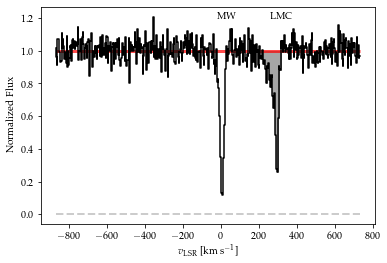

In [331]:
%matplotlib inline
SII_1250_mask = (vel_lsr >= 220.) &(vel_lsr <= 320.)

plt.step(vel_lsr,norm_flux,'k-',where='mid')
plt.xlabel(r'$v_{\rm{LSR}}$ [km s$^{-1}$]')
plt.ylabel(r'Normalized Flux')
plt.hlines(y=1.0,xmin=min(vel_lsr),xmax=max(vel_lsr),color='r',linewidth=3.,alpha=0.7)
plt.hlines(y=0.0,xmin=min(vel_lsr),xmax=max(vel_lsr),color='gray',linestyle='dashed',linewidth=2.,alpha=0.4)
#plt.xlim(xmin=180.,xmax=380.)
plt.fill_between(vel_lsr[SII_1250_mask],1.,norm_flux[SII_1250_mask],color='gray',alpha=0.7,step='mid')
plt.savefig('Normalized_Flux_LSR.pdf')
plt.text(-20.,1.2,'MW')
plt.text(260.,1.2,'LMC')
plt.show()

In [261]:
N_SII_arr = 3.768e14/(f*l0) * np.log(cont/flux)

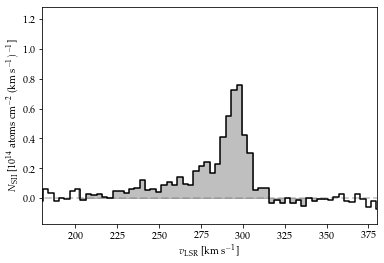

In [315]:
%matplotlib inline
SII_1250_mask = (vel_lsr >= 200.) &(vel_lsr <= 350.)
N_SII_array_2 = N_SII_arr/1e14
plt.step(vel_lsr,N_SII_arr/1e14,'k-',where='mid')
plt.xlabel(r'$v_{\rm{LSR}}$ [km s$^{-1}$]')
plt.ylabel(r'$N_{\rm{SII}}$ [10$^{14}$ atoms cm$^{-2}$ (km s$^{-1})^{-1}$]')
#plt.hlines(y=1.0,xmin=min(vel_lsr),xmax=max(vel_lsr),color='r',linewidth=3.,alpha=0.7)
plt.fill_between(vel_lsr[SII_1250_mask],N_SII_array_2[SII_1250_mask],color='gray',alpha=0.5,step='mid')
plt.hlines(y=0.0,xmin=min(vel_lsr),xmax=max(vel_lsr),color='gray',linestyle='dashed',linewidth=2.,alpha=0.4)
plt.xlim(xmin=180,xmax=380)
plt.savefig('N_SII_vs_velocity.pdf')
plt.show()

In [316]:
SII_1250_mask = (vel_lsr >= 220.) &(vel_lsr <= 320.)
MW_mask = (vel_lsr >= -100.) & (vel_lsr <= 100.) 
SII_1253_mask = (vel_lsr >=222.) & (vel_lsr <= 320.)

vel_1250 = vel_lsr[SII_1250_mask]
vel_1253 = vel_lsr[SII_1253_mask]
vel_MW = vel_lsr[MW_mask]

norm_1250 = norm_flux[SII_1250_mask]
norm_MW = norm_flux[MW_mask]

err_1250 = norm_err[SII_1250_mask]
err_MW = norm_err[MW_mask]

In [317]:
N_SIIs = []
for i in range(50000):
    norm_trial = norm_1250 + np.random.normal(0.,err_1250)
    
    norm_trial_mask = norm_trial >0
    
    vel_trial = vel_1250[norm_trial_mask]
    norm_trial = norm_trial[norm_trial_mask]
    
    N_SII_bin = 3.678e14/(f*l0) * np.log(1/norm_trial)
    N_SII_int = simps(N_SII_bin,vel_trial)
    N_SIIs.append(N_SII_int)
    #print(N_SII_int)

In [318]:
N_SII_1253s = []
for i in range(50000):
    norm_trial = norm_1253 + np.random.normal(0.,err_1253)
    
    norm_trial_mask = norm_trial >0
    
    vel_trial = vel_1253[norm_trial_mask]
    norm_trial = norm_trial[norm_trial_mask]
    
    N_SII_bin = 3.678e14/(f_153*l0_53) * np.log(1/norm_trial)
    N_SII_int = simps(N_SII_bin,vel_trial)
    N_SII_1253s.append(N_SII_int)
    #print(N_SII_int)

NameError: name 'f_153' is not defined

In [319]:
N_SII_MWs = []
for i in range(50000):
    norm_trial = norm_MW + np.random.normal(0.,err_MW)
    
    norm_trial_mask = norm_trial >0
    
    vel_trial = vel_MW[norm_trial_mask]
    norm_trial = norm_trial[norm_trial_mask]
    
    N_SII_bin = 3.678e14/(f*l0) * np.log(1/norm_trial)
    N_SII_int = simps(N_SII_bin,vel_trial)
    N_SII_MWs.append(N_SII_int)
    #print(N_SII_int)

In [320]:
N_SII_avg_lin = np.mean(N_SIIs)
N_SII_avg = np.log10(np.mean(N_SIIs))


N_SII_MW_lin = np.mean(N_SII_MWs)
N_SII_MW_avg = np.log10(N_SII_MW_lin)

N_SII_sigma_lin = np.std(N_SIIs)
N_SII_sigma = np.std(N_SIIs)/(np.log(10) * N_SII_avg_lin)
#N_SII_1253_sigma = np.std(N_SII_1253s)/(np.log(10) * np.mean(N_SII_1253s))


N_SII_MW_sigma_lin = np.std(N_SII_MWs)
N_SII_MW_sigma = N_SII_MW_sigma_lin/(np.log(10) * N_SII_MW_lin)

/opt/anaconda3/lib/python3.8/site-packages/numpy/core/_methods.py:261: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/opt/anaconda3/lib/python3.8/site-packages/numpy/core/_methods.py:221: RuntimeWarning: invalid value encountered in true_divide
  arrmean = um.true_divide(arrmean, div, out=arrmean, casting='unsafe',
/opt/anaconda3/lib/python3.8/site-packages/numpy/core/_methods.py:253: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)
/opt/anaconda3/lib/python3.8/site-packages/numpy/core/fromnumeric.py:3419: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/opt/anaconda3/lib/python3.8/site-packages/numpy/core/_methods.py:188: RuntimeWarning: invalid value encountered in double_scalars
  ret = ret.dtype.type(ret / rcount)


In [321]:
print('N_SII1250 = %.3f +/- %.3f' % (N_SII_avg,N_SII_sigma))
#print('N_SII1253 = %.3f +/- %.3f' % (np.log10(np.mean(N_SII_1253s)),N_SII_1253_sigma))
print('N_SII1250MW = %.3f +/- %.3f' % (N_SII_MW_avg,N_SII_MW_sigma))

N_SII1250 = 15.238 +/- 0.020
N_SII1250MW = 15.385 +/- 0.024


In [309]:
N_SII_avg_lin/1e15

1.732043430683419

In [277]:
HI_dat = np.genfromtxt('../Data/spectrum.txt',skip_header=14,skip_footer=780)

In [300]:
N_SII_sigma_lin/1e13

8.192542125836166

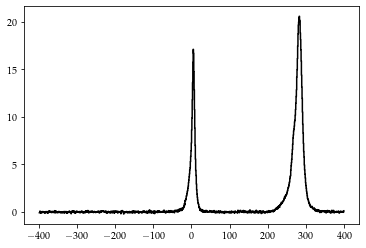

In [283]:
plt.step(vel_HI,TB,'k-',where='mid')
plt.show()

In [340]:
LMC_vel = (vel_HI > 200.) & (vel_HI < 350.)
MW_vel = (vel_HI > -100.) & (vel_HI < 100.)

In [341]:
NHI_LMC = -1.8223e18 * simps(TB[LMC_vel],x=vel_HI[LMC_vel])
NHI_MW = -1.8223e18 * simps(TB[MW_vel],x=vel_HI[MW_vel])

In [342]:
np.log10(NHI_MW)

20.581053984839635

In [344]:
SII_HI = N_SII_avg - np.log10(NHI_LMC)+ 4.88
SII_HI_MW = N_SII_MW_avg - np.log10(NHI_MW)+ 4.88

In [346]:
SII_HI
SII_HI_MW

-0.3157182854148397

In [337]:
np.log10(NHI_LMC)

20.98139526105909

In [347]:
min(wl)

1247.0022

In [348]:
max(wl)

1253.6924

In [349]:
min(vel)

-857.680001465246

In [350]:
max(vel)

746.1130405725295